## Even/Odd Router

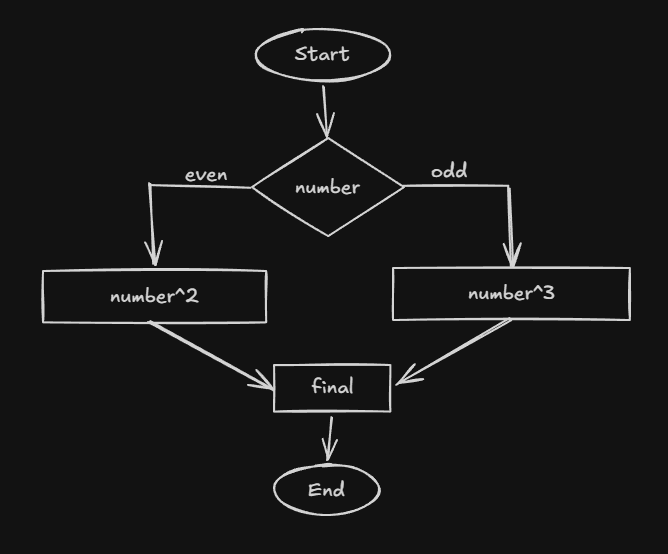

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [3]:
class AgentState(TypedDict):
    number: int
    finalNumber: int

In [4]:
def check(state: AgentState) -> AgentState:
    return state


def router(state: AgentState) -> AgentState:
    """This node checks if the number is even"""

    if state['number'] % 2 == 0:
        return "even"
    else:
        return "odd"
    
def square(state: AgentState) -> AgentState:
    """This node squares the number"""

    state['finalNumber'] = state['number'] ** 2
    return state

def cube(state: AgentState) -> AgentState:
    """This node cubes the number"""

    state['finalNumber'] = state['number'] ** 3
    return state


In [5]:
graph = StateGraph(AgentState)

graph.add_node("check", check)
graph.add_node("square", square)
graph.add_node("cube", cube)

graph.add_edge(START, "check")
graph.add_conditional_edges(
    "check",
    router, 
        {
            "even": "square",
            "odd": "cube"
    
    })

graph.add_edge("square", END)
graph.add_edge("cube", END)

app = graph.compile()

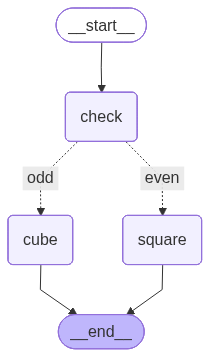

In [6]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
initial_state = AgentState(number=7, finalNumber=0)
print(app.invoke(initial_state))

{'number': 7, 'finalNumber': 343}
